Lab 8


Categorical Naive Bayes
Accuracy : 0.8

Confusion Matrix
[[1 1]
 [1 7]]

Classification Report
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.88      0.88      0.88         8

    accuracy                           0.80        10
   macro avg       0.69      0.69      0.69        10
weighted avg       0.80      0.80      0.80        10


Prediction
Play Tennis : No

Probabilities
No : 0.9256
Yes : 0.0744

Decision Tree Accuracy : 0.8
Logistic Regression Accuracy : 0.4

Model Comparison
Naive Bayes : 0.8
Decision Tree : 0.8
Logistic Regression : 0.4


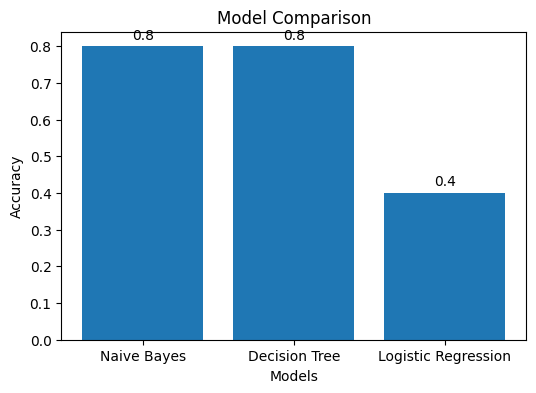

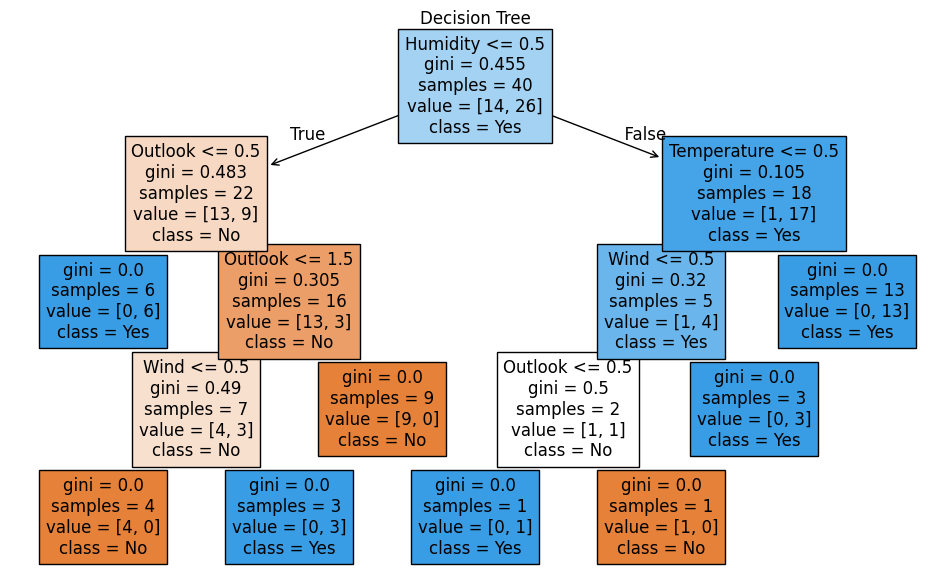

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("dataset.csv")

# Remove serial number column
data.drop("No", axis=1, inplace=True)

# Features and target
X = data.drop("Play Tennis", axis=1)
y = data["Play Tennis"]

# Encoding
encoder = OrdinalEncoder()
X = encoder.fit_transform(X)

label = LabelEncoder()
y = label.fit_transform(y)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Naive Bayes
nb = CategoricalNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

print("\nCategorical Naive Bayes")
print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Predict new data
sample = pd.DataFrame({
    "Outlook": ["Sunny"],
    "Temperature": ["Cool"],
    "Humidity": ["High"],
    "Wind": ["Strong"]
})

sample = encoder.transform(sample)

pred = nb.predict(sample)
prob = nb.predict_proba(sample)

print("\nPrediction")
print("Play Tennis :", label.inverse_transform(pred)[0])

print("\nProbabilities")
for i, j in zip(label.classes_, prob[0]):
    print(i, ":", round(j, 4))

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\nDecision Tree Accuracy :", accuracy_score(y_test, dt_pred))

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy :", accuracy_score(y_test, lr_pred))

# Compare models
nb_acc = accuracy_score(y_test, y_pred)
dt_acc = accuracy_score(y_test, dt_pred)
lr_acc = accuracy_score(y_test, lr_pred)

print("\nModel Comparison")
print("Naive Bayes :", round(nb_acc, 2))
print("Decision Tree :", round(dt_acc, 2))
print("Logistic Regression :", round(lr_acc, 2))

# Accuracy graph
models = ["Naive Bayes", "Decision Tree", "Logistic Regression"]
accuracy = [nb_acc, dt_acc, lr_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i in range(len(models)):
    plt.text(i, accuracy[i] + 0.02, round(accuracy[i], 2), ha="center")

plt.show()

# Decision Tree graph
plt.figure(figsize=(12,7))

plot_tree(
    dt,
    feature_names=["Outlook", "Temperature", "Humidity", "Wind"],
    class_names=label.classes_,
    filled=True
)

plt.title("Decision Tree")
plt.show()

Observation:

After encoding the categorical data and splitting the dataset into training and testing sets, the model achieved an accuracy of 80%, which means it correctly predicted 8 out of 10 test cases. From the confusion matrix, I observed that the model made only 2 incorrect predictions. When I tested the new weather condition (Sunny, Cool, High, Strong), the model predicted that the person would not play tennis ("No") with a confidence of 92.56%. I also compared the model with Decision Tree and Logistic Regression. Both Categorical Naive Bayes and Decision Tree achieved an accuracy of 80%, while Logistic Regression achieved only 40%. From this, I understood that Categorical Naive Bayes and Decision Tree are better suited for this small categorical dataset than Logistic Regression. 